In [1]:
# Datasets Loaded

In [2]:
print("Dataset folders ready!")

Dataset folders ready!


In [1]:
import os
import re
import numpy as np
import pandas as pd
import tensorflow as tf
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

from tqdm import tqdm
from sklearn.model_selection import train_test_split
from tensorflow.keras.layers import *
from tensorflow.keras.models import Model
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau
from tensorflow.keras import mixed_precision

mixed_precision.set_global_policy('mixed_float16')

print("TensorFlow:", tf.__version__)

INFO:tensorflow:Mixed precision compatibility check (mixed_float16): OK
Your GPU will likely run quickly with dtype policy mixed_float16 as it has compute capability of at least 7.0. Your GPU: NVIDIA GeForce RTX 4060 Laptop GPU, compute capability 8.9
TensorFlow: 2.10.1


In [2]:
import os
print("Current working directory:")
print(os.getcwd())

Current working directory:
c:\Users\Shrinivas\Desktop\MLB_VQA


In [3]:
import os
import pandas as pd

# ============================================================
# Correct Base Folders (MATCH YOUR FOLDER NAMES)
# ============================================================

TRAIN_BASE = "ImageClef-2019-VQA-Med-Training"
VAL_BASE   = "ImageClef-2019-VQA-Med-Validation"

TRAIN_QA_FILE = os.path.join(TRAIN_BASE, "All_QA_Pairs_train.txt")
VAL_QA_FILE   = os.path.join(VAL_BASE, "All_QA_Pairs_val.txt")

TRAIN_IMG_DIR = os.path.join(TRAIN_BASE, "Train_images")
VAL_IMG_DIR   = os.path.join(VAL_BASE, "Val_images")


# ============================================================
# QA Loader
# ============================================================

def load_qa_file(filepath, image_dir):

    data = []

    with open(filepath, "r", encoding="utf-8") as f:
        lines = f.readlines()

    for line in lines:

        # Format: image_id | question | answer
        parts = line.strip().split("|")

        if len(parts) >= 3:

            image_id = parts[0].strip()
            question = parts[1].strip()
            answer   = parts[2].strip()

            image_path = os.path.join(image_dir, image_id + ".jpg")

            data.append([image_path, question, answer])

    df = pd.DataFrame(data, columns=["image_path", "question", "answer"])

    return df


# ============================================================
# Load Train + Val
# ============================================================

train_df = load_qa_file(TRAIN_QA_FILE, TRAIN_IMG_DIR)
val_df   = load_qa_file(VAL_QA_FILE, VAL_IMG_DIR)

print("Train size:", len(train_df))
print("Val size:", len(val_df))

print("Sample row:")
print(train_df.head())

Train size: 12792
Val size: 2000
Sample row:
                                          image_path  \
0  ImageClef-2019-VQA-Med-Training\Train_images\s...   
1  ImageClef-2019-VQA-Med-Training\Train_images\s...   
2  ImageClef-2019-VQA-Med-Training\Train_images\s...   
3  ImageClef-2019-VQA-Med-Training\Train_images\s...   
4  ImageClef-2019-VQA-Med-Training\Train_images\s...   

                                            question                answer  
0                        what kind of image is this?  cta - ct angiography  
1                       is this a t1 weighted image?                    no  
2  what type of imaging modality is used to acqui...       us - ultrasound  
3                         is this a noncontrast mri?                    no  
4               what type of image modality is this?       xr - plain film  


In [4]:
def clean_text(text):
    text = str(text).lower()
    text = re.sub(r"[^a-z0-9 ]", " ", text)
    text = re.sub(r"\s+", " ", text)
    return text.strip()

train_df["question"] = train_df["question"].apply(clean_text)
val_df["question"] = val_df["question"].apply(clean_text)

train_df["answer"] = train_df["answer"].apply(
    lambda x: "sostok " + clean_text(x) + " eostok"
)

val_df["answer"] = val_df["answer"].apply(
    lambda x: "sostok " + clean_text(x) + " eostok"
)

In [5]:
max_q_len = 20
max_a_len = 15

# Question tokenizer
x_tokenizer = Tokenizer(oov_token="<OOV>")
x_tokenizer.fit_on_texts(train_df["question"])

x_train_pad = pad_sequences(
    x_tokenizer.texts_to_sequences(train_df["question"]),
    maxlen=max_q_len,
    padding='post'
)

x_val_pad = pad_sequences(
    x_tokenizer.texts_to_sequences(val_df["question"]),
    maxlen=max_q_len,
    padding='post'
)

x_vocab = len(x_tokenizer.word_index) + 1

# Answer tokenizer
y_tokenizer = Tokenizer(oov_token="<OOV>")
y_tokenizer.fit_on_texts(train_df["answer"])

y_train_pad = pad_sequences(
    y_tokenizer.texts_to_sequences(train_df["answer"]),
    maxlen=max_a_len,
    padding='post'
)

y_val_pad = pad_sequences(
    y_tokenizer.texts_to_sequences(val_df["answer"]),
    maxlen=max_a_len,
    padding='post'
)

y_vocab = len(y_tokenizer.word_index) + 1

print("Question vocab:", x_vocab)
print("Answer vocab:", y_vocab)

Question vocab: 101
Answer vocab: 2024


In [6]:
def load_image(path):
    img = tf.keras.preprocessing.image.load_img(path, target_size=(224,224))
    img = tf.keras.preprocessing.image.img_to_array(img)
    img = tf.keras.applications.resnet50.preprocess_input(img)
    return img

In [7]:
def create_dataset(x, y, image_paths, batch_size=8, training=True):

    def generator():
        for i in range(len(x)):
            img = load_image(image_paths[i])
            decoder_input = y[i][:-1]
            decoder_target = y[i][1:]
            yield (x[i], img, decoder_input), decoder_target

    dataset = tf.data.Dataset.from_generator(
        generator,
        output_signature=(
            (
                tf.TensorSpec((max_q_len,), tf.int32),
                tf.TensorSpec((224,224,3), tf.float32),
                tf.TensorSpec((max_a_len-1,), tf.int32),
            ),
            tf.TensorSpec((max_a_len-1,), tf.int32)
        )
    )

    if training:
        dataset = dataset.shuffle(1024).repeat()

    dataset = dataset.batch(batch_size)
    dataset = dataset.prefetch(tf.data.AUTOTUNE)

    return dataset


train_dataset = create_dataset(
    x_train_pad,
    y_train_pad,
    train_df["image_path"].values,
    batch_size=8,
    training=True
)

val_dataset = create_dataset(
    x_val_pad,
    y_val_pad,
    val_df["image_path"].values,
    batch_size=8,
    training=False
)

In [8]:
# -------- Image Backbone --------
cnn = tf.keras.applications.ResNet50(
    include_top=False,
    weights='imagenet',
    input_shape=(224,224,3)
)

cnn.trainable = False
for layer in cnn.layers[-20:]:
    layer.trainable = True

img_input = cnn.input
features = cnn.get_layer("conv5_block3_out").output
features = Reshape((49, 2048))(features)
features = Dense(1024, activation='relu')(features)

# -------- Question Encoder --------
q_input = Input(shape=(max_q_len,))
q_embed = Embedding(x_vocab, 100, mask_zero=True)(q_input)

q_out, q_h, q_c = LSTM(
    1024,
    return_sequences=True,
    return_state=True
)(q_embed)

# -------- MLB Attention --------
class MLB_Attention(tf.keras.layers.Layer):
    def __init__(self, joint_dim=512, **kwargs):
        super(MLB_Attention, self).__init__(**kwargs)
        self.joint_dim = joint_dim

    def build(self, input_shape):
        self.Wv = Dense(self.joint_dim, use_bias=False)
        self.Wq = Dense(self.joint_dim, use_bias=False)
        self.score = Dense(1, use_bias=False)
        super(MLB_Attention, self).build(input_shape)

    def call(self, inputs):
        v, q = inputs
        q = tf.expand_dims(q, 1)
        joint = tf.nn.tanh(self.Wv(v) * self.Wq(q))
        weights = tf.nn.softmax(self.score(joint), axis=1)
        return tf.reduce_sum(weights * v, axis=1)

    def get_config(self):
        config = super().get_config()
        config.update({"joint_dim": self.joint_dim})
        return config

attention = MLB_Attention(512)
context = attention([features, q_h])

# -------- Improved Decoder Initialization --------
decoder_init = Concatenate()([context, q_h])
decoder_init = Dense(1024, activation='tanh')(decoder_init)

# -------- Decoder --------
dec_input = Input(shape=(None,))

# Increased embedding size (100 → 256)
dec_embed = Embedding(y_vocab, 256, mask_zero=True)(dec_input)

dec_out, _, _ = LSTM(
    1024,
    return_sequences=True,
    return_state=True,
    dropout=0.3,
    recurrent_dropout=0.3
)(dec_embed, initial_state=[decoder_init, decoder_init])

output = TimeDistributed(
    Dense(y_vocab, activation='softmax', dtype='float32')
)(dec_out)

model = Model([q_input, img_input, dec_input], output)
model.summary()

Model: "model"
__________________________________________________________________________________________________
 Layer (type)                   Output Shape         Param #     Connected to                     
 input_1 (InputLayer)           [(None, 224, 224, 3  0           []                               
                                )]                                                                
                                                                                                  
 conv1_pad (ZeroPadding2D)      (None, 230, 230, 3)  0           ['input_1[0][0]']                
                                                                                                  
 conv1_conv (Conv2D)            (None, 112, 112, 64  9472        ['conv1_pad[0][0]']              
                                )                                                                 
                                                                                              

In [10]:
optimizer = tf.keras.optimizers.Adam(learning_rate=1e-4)

# Use standard sparse categorical crossentropy (compatible with all TF versions)
loss_fn = tf.keras.losses.SparseCategoricalCrossentropy(
    from_logits=False
)

model.compile(
    optimizer=optimizer,
    loss=loss_fn,
    metrics=['accuracy']
)

steps_per_epoch = len(train_df) // 8
val_steps = len(val_df) // 8

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=7,
    restore_best_weights=True
)

checkpoint = ModelCheckpoint(
    "best_imageclef_model.keras",
    monitor='val_loss',
    save_best_only=True
)

reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=4
)

history = model.fit(
    train_dataset,
    validation_data=val_dataset,
    epochs=100,
    steps_per_epoch=steps_per_epoch,
    validation_steps=val_steps,
    callbacks=[early_stop, checkpoint, reduce_lr]
)

Epoch 1/100


1599/1599 [==============================] - 200s 118ms/step - loss: nan - accuracy: 0.6555 - val_loss: 0.7954 - val_accuracy: 0.5878 - lr: 1.0000e-04
Epoch 2/100
1599/1599 [==============================] - 187s 117ms/step - loss: 0.4875 - accuracy: 0.6995 - val_loss: 0.6211 - val_accuracy: 0.6629 - lr: 1.0000e-04
Epoch 3/100
1599/1599 [==============================] - 187s 117ms/step - loss: 0.4323 - accuracy: 0.7200 - val_loss: 0.5863 - val_accuracy: 0.6771 - lr: 1.0000e-04
Epoch 4/100
1599/1599 [==============================] - 187s 117ms/step - loss: 0.3946 - accuracy: 0.7367 - val_loss: 0.5324 - val_accuracy: 0.6944 - lr: 1.0000e-04
Epoch 5/100
1599/1599 [==============================] - 187s 117ms/step - loss: 0.3623 - accuracy: 0.7508 - val_loss: 0.5193 - val_accuracy: 0.7007 - lr: 1.0000e-04
Epoch 6/100
1599/1599 [==============================] - 187s 117ms/step - loss: 0.3332 - accuracy: 0.7641 - val_loss: 0.4887 - val_accuracy: 0.7100 - lr: 1.0000e-04
Epoch 7/100
1599/15

In [11]:
reverse_target_word_index = y_tokenizer.index_word
target_word_index = y_tokenizer.word_index

def decode_sequence(input_seq, image_path, beam_width=5):

    img = load_image(image_path)
    img = np.expand_dims(img, axis=0)

    start_token = target_word_index['sostok']
    end_token = target_word_index['eostok']

    sequences = [[ [start_token], 0.0 ]]

    for _ in range(max_a_len):

        all_candidates = []

        for seq, score in sequences:

            if seq[-1] == end_token:
                all_candidates.append((seq, score))
                continue

            target_seq = np.array([seq])
            preds = model.predict([input_seq, img, target_seq], verbose=0)
            probs = preds[0, -1, :]

            top_indices = np.argsort(probs)[-beam_width:]

            for idx in top_indices:
                candidate = seq + [idx]
                candidate_score = score - np.log(probs[idx] + 1e-10)
                all_candidates.append((candidate, candidate_score))

        ordered = sorted(all_candidates, key=lambda tup: tup[1])
        sequences = ordered[:beam_width]

    best_seq = sequences[0][0]

    decoded = []
    for idx in best_seq:
        word = reverse_target_word_index.get(idx, "")
        if word == 'eostok':
            break
        if word != 'sostok':
            decoded.append(word)

    return " ".join(decoded)

In [12]:
from nltk.translate.bleu_score import sentence_bleu, SmoothingFunction
from tqdm import tqdm
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import numpy as np

reverse_target_word_index = y_tokenizer.index_word
target_word_index = y_tokenizer.word_index


def evaluate_validation(show_samples=5):

    smoothie = SmoothingFunction().method4
    total_bleu = 0
    total_tokens = 0
    correct_tokens = 0

    print("Running validation evaluation...\n")

    for i in tqdm(range(len(x_val_pad))):

        image_path = val_df["image_path"].iloc[i]

        # ---- Prediction ----
        pred = decode_sequence(
            x_val_pad[i].reshape(1, max_q_len),
            image_path
        )

        # ---- Ground Truth ----
        true = val_df["answer"].iloc[i]
        true = true.replace("sostok ", "").replace(" eostok", "")

        question = val_df["question"].iloc[i]

        # ---- Token Accuracy ----
        pred_tokens = pred.split()
        true_tokens = true.split()

        min_len = min(len(pred_tokens), len(true_tokens))

        for j in range(min_len):
            if pred_tokens[j] == true_tokens[j]:
                correct_tokens += 1
            total_tokens += 1

        # ---- BLEU ----
        if len(pred_tokens) > 0:
            total_bleu += sentence_bleu(
                [true_tokens],
                pred_tokens,
                smoothing_function=smoothie
            )

        # ---- Show Few Samples ----
        if i < show_samples:

            img = mpimg.imread(image_path)

            plt.figure(figsize=(12,4))

            plt.subplot(1,2,1)
            plt.imshow(img)
            plt.axis("off")

            plt.subplot(1,2,2)
            plt.text(
                0.5, 0.5,
                f"Question:\n{question}\n\n"
                f"Actual:\n{true}\n\n"
                f"Predicted:\n{pred}",
                horizontalalignment='center',
                verticalalignment='center',
                wrap=True
            )
            plt.axis("off")

            plt.show()
            print("-" * 50)

    # ---- Final Metrics ----
    token_accuracy = correct_tokens / total_tokens if total_tokens > 0 else 0
    bleu_score = total_bleu / len(x_val_pad)

    print("\n====================================")
    print("Validation Token Accuracy:", round(token_accuracy, 4))
    print("Validation BLEU Score:", round(bleu_score, 4))
    print("====================================")

Running validation evaluation...



  0%|          | 0/2000 [00:00<?, ?it/s]

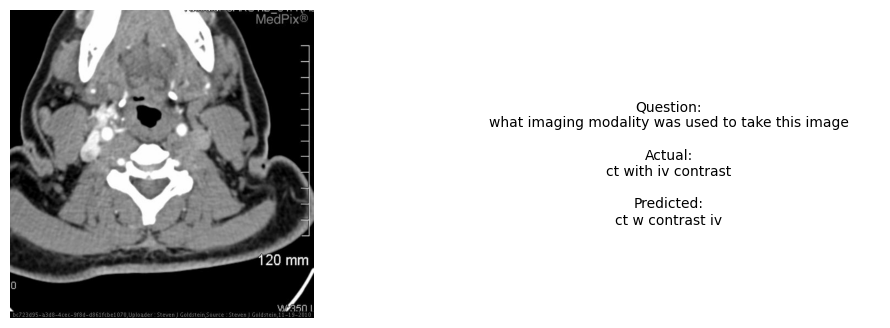

  0%|          | 1/2000 [00:06<3:31:09,  6.34s/it]

--------------------------------------------------


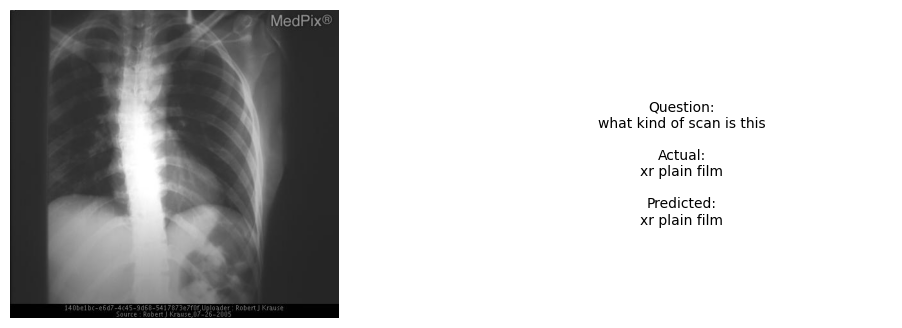

  0%|          | 2/2000 [00:07<1:45:17,  3.16s/it]

--------------------------------------------------


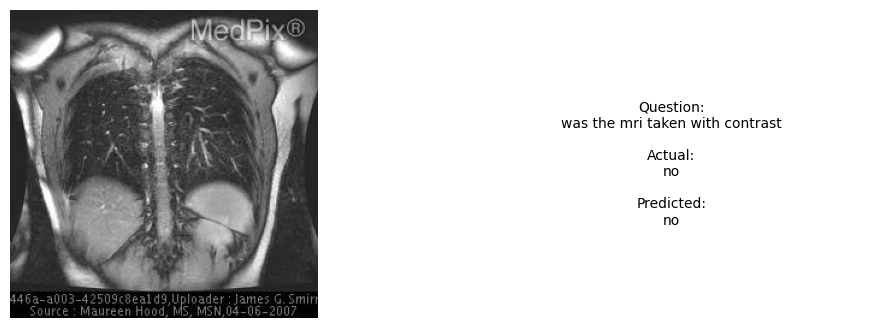

  0%|          | 3/2000 [00:07<1:03:12,  1.90s/it]

--------------------------------------------------


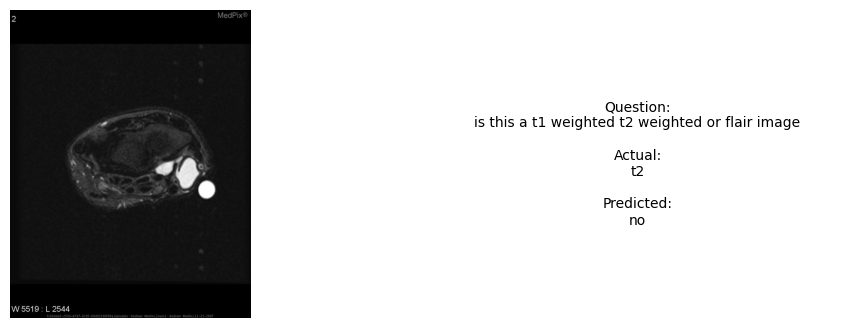

  0%|          | 4/2000 [00:08<43:58,  1.32s/it]  

--------------------------------------------------


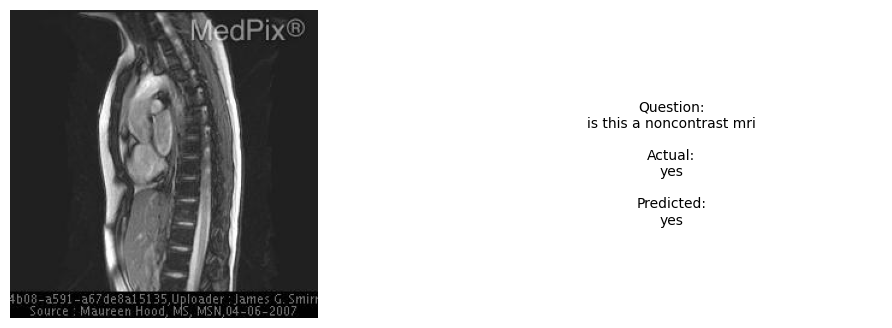

  0%|          | 5/2000 [00:08<35:36,  1.07s/it]

--------------------------------------------------


100%|██████████| 2000/2000 [31:49<00:00,  1.05it/s]


Validation Token Accuracy: 0.5604
Validation BLEU Score: 0.4397


In [13]:
evaluate_validation(show_samples=5)

In [14]:
def load_category_data(category_file, image_dir):

    with open(category_file, 'r', encoding='latin-1') as file:
        lines = file.readlines()

    data_list = [line.strip().split('|') for line in lines]
    df = pd.DataFrame(data_list, columns=['image', 'question', 'answer'])

    # Apply SAME cleaning used during training
    df["question"] = df["question"].apply(clean_text)
    df["answer"] = df["answer"].apply(
        lambda x: "sostok " + clean_text(x) + " eostok"
    )

    # Filter using same max lengths used in model
    df = df[
        (df["question"].str.split().str.len() <= max_q_len) &
        (df["answer"].str.split().str.len() <= max_a_len)
    ].copy().reset_index(drop=True)

    # Tokenize
    x_seq = x_tokenizer.texts_to_sequences(df["question"])
    x_pad = pad_sequences(x_seq, maxlen=max_q_len, padding='post')

    y_seq = y_tokenizer.texts_to_sequences(df["answer"])
    y_pad = pad_sequences(y_seq, maxlen=max_a_len, padding='post')

    # Image paths
    image_paths = [
        os.path.join(image_dir, img + ".jpg")
        for img in df["image"]
    ]

    return x_pad, y_pad, image_paths

In [15]:
# Convert padded target sequence back to text

reverse_target_word_index = y_tokenizer.index_word

def seq2summary(input_seq):
    words = []
    for idx in input_seq:
        if idx != 0:  # ignore padding
            word = reverse_target_word_index.get(idx, "")
            words.append(word)
    return " ".join(words)

In [16]:
from nltk.translate.bleu_score import corpus_bleu, SmoothingFunction
from tqdm import tqdm

def evaluate_subset(x_pad, y_pad, image_paths):

    correct = 0
    total = len(x_pad)

    references = []
    hypotheses = []

    for i in tqdm(range(total), desc="Evaluating", unit="sample"):

        input_seq = x_pad[i].reshape(1, max_q_len)
        image_path = image_paths[i]

        pred = decode_sequence(input_seq, image_path).strip()

        true = seq2summary(y_pad[i])
        true = true.replace("sostok ", "").replace(" eostok", "").strip()

        # ----- Exact Match Accuracy -----
        if pred == true:
            correct += 1

        references.append([true.split()])
        hypotheses.append(pred.split())

    accuracy = correct / total if total > 0 else 0

    # ----- BLEU-1 (Unigram BLEU) -----
    smooth = SmoothingFunction().method1

    bleu = corpus_bleu(
        references,
        hypotheses,
        weights=(1, 0, 0, 0),   
        smoothing_function=smooth
    ) if total > 0 else 0

    return accuracy, bleu

In [17]:
VAL_BASE = "ImageClef-2019-VQA-Med-Validation"
VAL_IMG_DIR = os.path.join(VAL_BASE, "Val_images")
CATEGORY_DIR = os.path.join(VAL_BASE, "QAPairsByCategory")

# C1 Modality
x_mod, y_mod, img_mod = load_category_data(
    os.path.join(CATEGORY_DIR, "C1_Modality_val.txt"),
    VAL_IMG_DIR
)

# C2 Plane
x_plane, y_plane, img_plane = load_category_data(
    os.path.join(CATEGORY_DIR, "C2_Plane_val.txt"),
    VAL_IMG_DIR
)

# C3 Organ
x_organ, y_organ, img_organ = load_category_data(
    os.path.join(CATEGORY_DIR, "C3_Organ_val.txt"),
    VAL_IMG_DIR
)

# C4 Abnormality
x_abn, y_abn, img_abn = load_category_data(
    os.path.join(CATEGORY_DIR, "C4_Abnormality_val.txt"),
    VAL_IMG_DIR
)

In [20]:
# # Overall validation set

# x_val_eval = x_val_pad
# y_val_eval = y_val_pad
# img_val_eval = val_df["image_path"].tolist()

# acc_overall, bleu_overall = evaluate_subset(
#     x_val_eval, y_val_eval, img_val_eval
# )

In [18]:
acc_mod, bleu_mod = evaluate_subset(x_mod, y_mod, img_mod)
acc_plane, bleu_plane = evaluate_subset(x_plane, y_plane, img_plane)
acc_organ, bleu_organ = evaluate_subset(x_organ, y_organ, img_organ)
acc_abn, bleu_abn = evaluate_subset(x_abn, y_abn, img_abn)

Evaluating: 100%|██████████| 498/498 [29:31<00:00,  3.56s/sample]


In [19]:
print("\n================ FINAL RESULTS ================\n")

print(f"{'Metric':<15}{'Modality':<12}{'Plane':<12}{'Organ':<12}{'Abnormality':<15}")
print("-" * 75)

print(f"{'Accuracy':<15}"
      # f"{acc_overall*100:<12.2f}" 
      f"{acc_mod*100:<12.2f}"
      f"{acc_plane*100:<12.2f}"
      f"{acc_organ*100:<12.2f}"
      f"{acc_abn*100:<15.2f}")

print(f"{'BLEU':<15}"
      # f"{bleu_overall*100:<12.2f}"
      f"{bleu_mod*100:<12.2f}"
      f"{bleu_plane*100:<12.2f}"
      f"{bleu_organ*100:<12.2f}"
      f"{bleu_abn*100:<15.2f}")

print("\n================================================")


================ FINAL RESULTS ================

Metric         Modality    Plane       Organ       Abnormality    
---------------------------------------------------------------------------
Accuracy       56.40       73.20       71.80       7.03           
BLEU           60.16       72.17       73.78       4.35           

